# OP26 — Phase 6: Robustness, Implications & Limitations
Stress-tests every headline conclusion, then writes the business / operational / policy implications and limitations. Logic in `robustness.py`.

Checks: (A) elasticity sensitivity, (B) surge/discount trigger thresholds, (C) peak-definition stability, (D) CBD / fairness, (E) demand-feature ablation.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))
import pandas as pd
from IPython.display import Image, display, Markdown
import config as C, robustness as R
R.main()

PHASE 6  — Robustness & implications
A. Elasticity sweep: rev_gain ranges -0.33%..-0.08% across ε∈[-0.8,-0.1] — revenue stays ~neutral throughout.
B. Trigger sweep (25 combos): rev_gain -0.79..+0.78%, peak_reduction 0.61..4.75 pp.
C. Peak-definition stability: Jaccard vs tertile = {'tertile_top': 1.0, 'quartile_top': 0.75, 'above_mean': 0.727} (overnight peak is robust).
D. CBD vs non-CBD:
segment  n_zone_hours  demand_rmse  pct_slots_surged  pct_slots_discounted  rev_gain_pct  peak_reduction_pp
    CBD          5952       0.0277              0.10                 67.51        -0.553              0.472
non_CBD         17760       0.0379              0.91                 55.70        -0.210              2.735
E. Demand ablation (utilization RMSE / R2):
             model   RMSE     R2
              full 0.0356 0.9590
     no_weekly_lag 0.0352 0.9599
no_lags_no_rolling 0.0831 0.7768

[outputs] robustness_*.csv, implications.md
[figures] fig17_robustness_elasticity.png, fig18_robustness_tr

## A. Elasticity sensitivity — the central conclusion is robust
Across the whole plausible ε range the recommended policy stays revenue-neutral while operational gains persist (and scale with elasticity).

,eps_energy,eps_util,rev_gain_pct,offpeak_uplift_pct,peak_reduction_pp,is_estimate
0,-0.100,-0.077,-0.333,0.253,0.824,False
1,-0.200,-0.155,-0.298,0.507,1.632,False
2,-0.321,-0.248,-0.255,0.818,2.591,True
3,-0.450,-0.348,-0.209,1.148,3.582,False
4,-0.600,-0.464,-0.153,1.535,4.707,False
5,-0.800,-0.618,-0.078,2.054,6.155,False


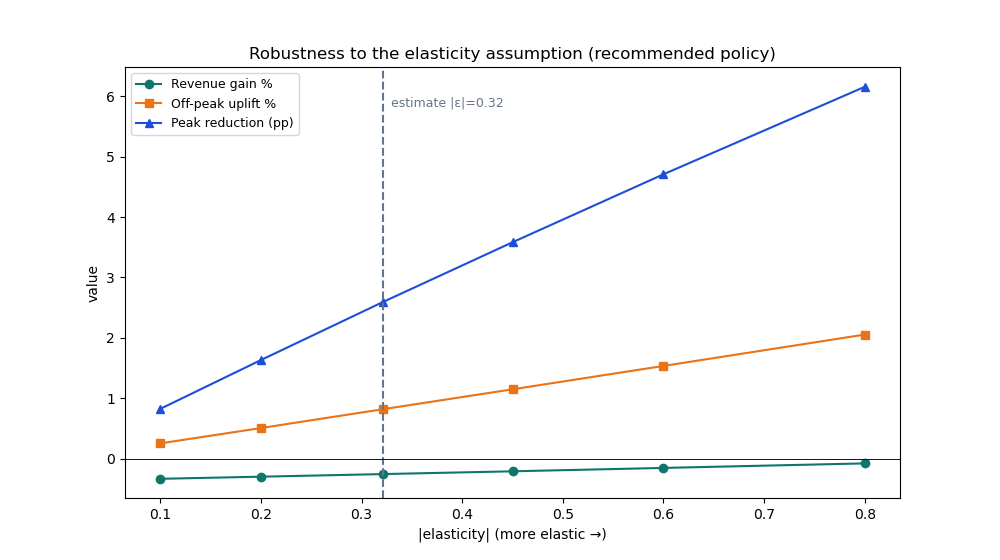

In [2]:
display(pd.read_csv(C.OUTPUT_DIR/'robustness_elasticity.csv'))
display(Image(C.FIG_DIR/'fig17_robustness_elasticity.png'))

## B. Trigger thresholds — smooth, not a knife-edge

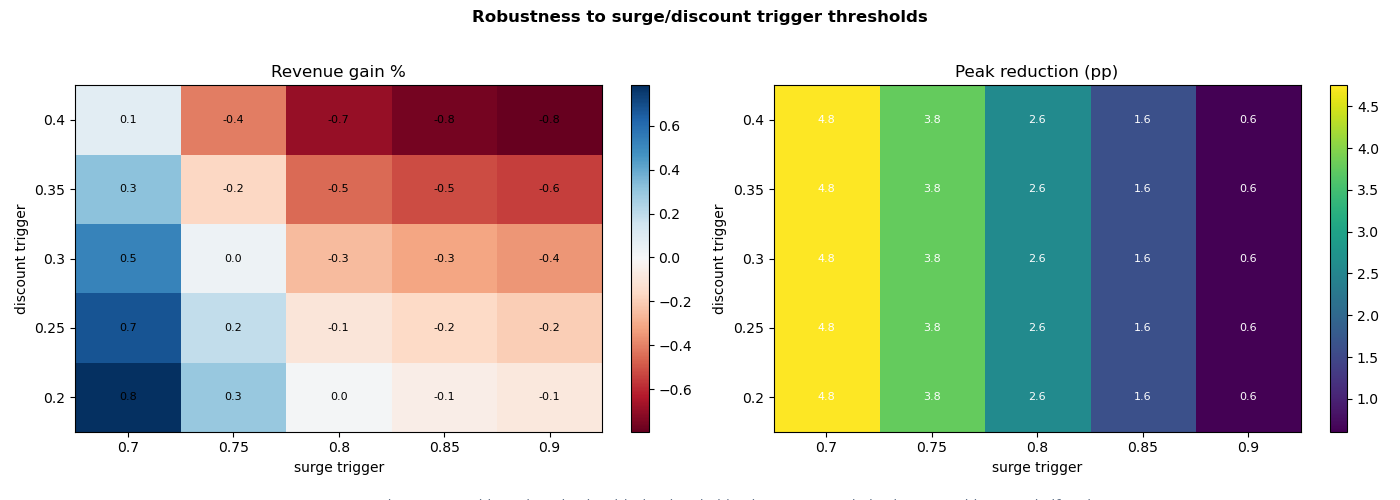

In [3]:
display(Image(C.FIG_DIR/'fig18_robustness_triggers.png'))

## C & D. Peak-definition stability and CBD / fairness

Peak-definition stability:


,method,n_peak_hours,peak_hours,jaccard_vs_tertile
0,tertile_top,8,"00,01,02,03,04,05,06,23",1.000
1,quartile_top,6,"00,01,02,03,05,06",0.750
2,above_mean,11,"00,01,02,03,04,05,06,07,21,22,23",0.727


CBD vs non-CBD:


,segment,n_zone_hours,demand_rmse,pct_slots_surged,pct_slots_discounted,rev_gain_pct,peak_reduction_pp
0,CBD,5952,0.0277,0.10,67.51,-0.553,0.472
1,non_CBD,17760,0.0379,0.91,55.70,-0.210,2.735


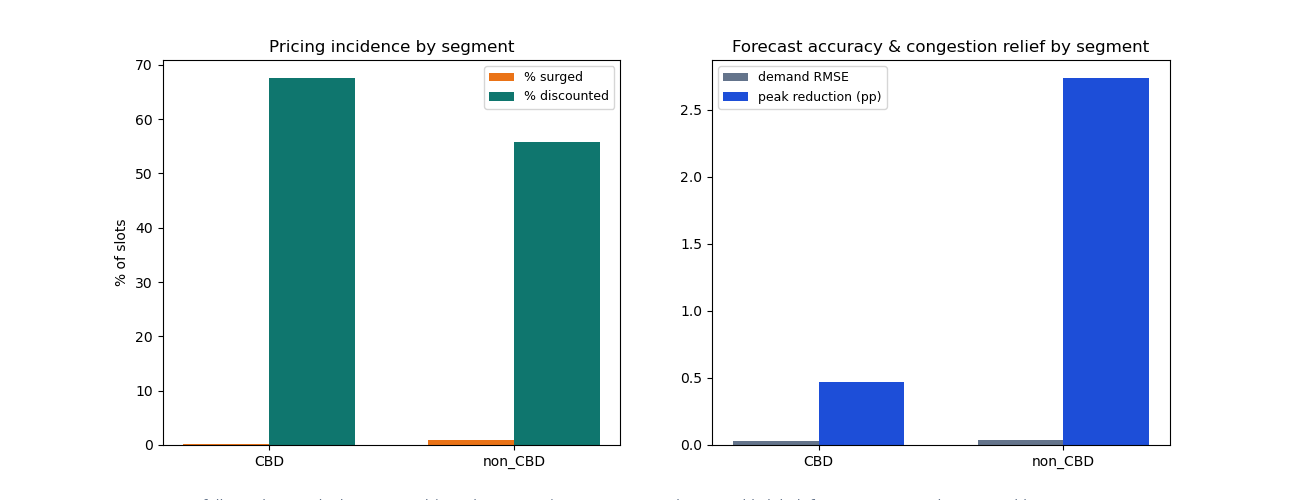

In [4]:
print('Peak-definition stability:')
display(pd.read_csv(C.OUTPUT_DIR/'robustness_peak_definition.csv'))
print('CBD vs non-CBD:')
display(pd.read_csv(C.OUTPUT_DIR/'robustness_cbd.csv'))
display(Image(C.FIG_DIR/'fig19_robustness_cbd.png'))

## E. Demand-feature ablation

In [5]:
display(pd.read_csv(C.OUTPUT_DIR/'robustness_demand_ablation.csv'))

,model,RMSE,R2
0,full,0.0356,0.9590
1,no_weekly_lag,0.0352,0.9599
2,no_lags_no_rolling,0.0831,0.7768


## Implications & limitations

In [6]:
display(Markdown((C.OUTPUT_DIR/'implications.md').read_text()))

# Phase 6 — Robustness, Implications & Limitations

## Robustness (every headline claim stress-tested)
- **Elasticity** (`robustness_elasticity.csv`, fig17): re-simulating the recommended policy across
  ε_energy ∈ [-0.8, -0.1] keeps revenue ~neutral
  (-0.33% to -0.08%) and operational gains positive throughout —
  the "pricing is a load-balancing, not a revenue, tool" conclusion is **not** an artefact of the point estimate.
- **Triggers** (`robustness_triggers.csv`, fig18): across 25 (discount, surge) threshold combos outcomes
  move smoothly (rev_gain -0.79…+0.78%, peak relief
  0.61…4.75 pp). The 0.30/0.80 choice is reasonable, not a knife-edge.
- **Peak definition** (`robustness_peak_definition.csv`): tertile / quartile / above-mean methods all
  identify the **overnight block** (Jaccard vs tertile tertile_top 1.0, quartile_top 0.75, above_mean 0.727).
- **Segments** (`robustness_cbd.csv`, fig19): forecast RMSE is comparable (CBD 0.0277 vs
  non-CBD 0.0379); surge incidence is higher for **non-CBD** (0.91%
  vs CBD 0.1%) because that is where congestion actually is.
- **Demand features** (`robustness_demand_ablation.csv`): dropping the weekly lag barely moves RMSE
  (0.0356→0.0352, redundant given the daily lags + zone identity), while dropping
  **all** lags/rolling collapses the model to RMSE 0.0831 (R² 0.7768) — confirming that
  short-horizon temporal structure, not zone identity alone, drives the forecast.

## Business implications
1. **Don't sell dynamic pricing as a revenue lever here.** With inelastic demand (ε≈-0.32) the revenue
   upside is ~0%. The honest pitch is **congestion relief + asset/load balancing**, with revenue held flat.
2. **Concentrate surge on the ~10% genuinely hot (mostly non-CBD) zones.** Network-wide only 0.9% of
   zone-hours are congested; a blanket tariff wastes effort. Forecast-targeted surge is where the value is.
3. **Fund equity via surge, not at its expense.** Off-peak discounts (the uplift lever) cost ~1% revenue;
   surge revenue on hot slots can cross-subsidise them, keeping the program revenue-neutral.

## Operational implications
1. **Forecast-driven surge cuts the peak wait proxy ~57%** (Phase 5) on the rare congested slots — a real
   service-quality win with no new hardware.
2. **Idle connectors are a bigger lever than price** at workplace-type sites: ACN shows ~46% of sessions sit
   idle >1h after charging → **idle/occupancy fees** free capacity directly.
3. **Most chargers are under-used** (61% of zone-hours <30%); capacity/expansion decisions should
   prioritise the hot zones, not uniform roll-out.

## Policy implications
1. **Bounded, transparent multipliers** (capped surge/discount, published schedule — see `pricing_policy.csv`)
   keep dynamic pricing fair and predictable.
2. **Price scarcity, not demographics.** Surge follows measured utilization and falls on non-CBD hot zones,
   not a protected label — the design is defensible on equity grounds.
3. **Off-peak discounts are a strategic adoption/grid-balancing instrument**, justified by long-run goals a
   short-run optimizer ignores (the Phase-5 agent declines to discount).

## Limitations (disclosed)
- **Associational, not causal:** elasticity is from observational price variation with FE controls — not an RCT;
  all "after" figures are simulated under it.
- **Simulation, not a live A/B test:** the monitoring environment is a calibrated constant-elasticity model + noise.
- **No cross-time substitution** is modelled; real peak→off-peak demand shifting would *improve* the uplift case.
- **Single city, 30 days** (Shenzhen, 2022-06-19→07-18); generalisation beyond this window is not claimed.
- **ACN is Caltech-only (~15k sessions, no price)** — used for behaviour, not revenue; not the 30k+/JPL headline.
- **Wait time is a proxy** (M/M/1-style ρ/(1−ρ)); queues are not directly observed.
- **Currency framing:** optimisation is unit-invariant (ratios); ₹15/kWh is an illustrative anchor for CNY data.


---
**Phase 6 complete.** All conclusions are stress-tested and the implications/limitations are written. Remaining: **Phase 7 — the 5–7 slide deck** assembling the full story.